# Notebook 01 – Data Preprocessing (NSL-KDD)

**Pipeline stages covered:**
1. Load `KDDTrain+.arff` and `KDDTest+.arff` from `data/NSL-KDD/`
2. Exploratory visualization (class distribution, feature dtypes)
3. Feature engineering
   - Drop zero-variance column (`is_host_login`)
   - Convert binary-string columns to integers
   - One-hot encode nominal categoricals (`protocol_type`, `service`, `flag`)
4. Label encoding (`normal`→1, `anomaly`→0) via `LabelEncoder`
5. Feature scaling: `MinMaxScaler` fitted **only on train set** (no leakage)
6. Persist arrays + metadata to `data/processed-nslkdd/`  
   Persist scaler + label encoder to `model/nsl-kdd/`

> **Data leakage note:** The NSL-KDD benchmark already provides a canonical
> train / test split (`KDDTrain+` / `KDDTest+`).  
> We use that split **directly** — no random re-splitting needed.  
> The scaler is fitted **only on the training set**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.io import arff
import joblib
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

print('✓ Imports OK')

✓ Imports OK


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────
DATA_DIR    = '../../data/NSL-KDD'
OUTPUT_DIR  = '../../data/processed-nslkdd'
MODEL_DIR   = '../../model/nsl-kdd'
RANDOM_STATE = 42

TRAIN_FILE  = f'{DATA_DIR}/KDDTrain+.arff'
TEST_FILE   = f'{DATA_DIR}/KDDTest+.arff'

# Nominal categoricals that need one-hot encoding
CAT_COLS    = ['protocol_type', 'service', 'flag']

# Binary-string columns → cast to int (0/1)
BIN_COLS    = ['land', 'logged_in', 'is_guest_login']

# Zero-variance column in the training set → drop
DROP_COLS   = ['is_host_login']

LABEL_COL   = 'class'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

print(f'Train file : {os.path.abspath(TRAIN_FILE)}')
print(f'Test  file : {os.path.abspath(TEST_FILE)}')
print(f'Output dir : {os.path.abspath(OUTPUT_DIR)}')
print(f'Model  dir : {os.path.abspath(MODEL_DIR)}')

Train file : e:\Documents\Programming\Python\project\AI\Transformer DDoS Detector\data\NSL-KDD\KDDTrain+.arff
Test  file : e:\Documents\Programming\Python\project\AI\Transformer DDoS Detector\data\NSL-KDD\KDDTest+.arff
Output dir : e:\Documents\Programming\Python\project\AI\Transformer DDoS Detector\data\processed-nslkdd
Model  dir : e:\Documents\Programming\Python\project\AI\Transformer DDoS Detector\model\nsl-kdd


## 1 · Load NSL-KDD Data

In [3]:
def load_arff(path):
    """Load an ARFF file into a pandas DataFrame, decoding byte strings."""
    with open(path, 'r') as f:
        content = f.read()
    data, meta = arff.loadarff(io.StringIO(content))
    df = pd.DataFrame(data)
    # Decode byte strings produced by scipy
    for col in df.select_dtypes(['object']).columns:
        df[col] = df[col].str.decode('utf-8')
    return df

df_train = load_arff(TRAIN_FILE)
df_test  = load_arff(TEST_FILE)

print(f'Train shape : {df_train.shape}')
print(f'Test  shape : {df_test.shape}')

Train shape : (125973, 42)
Test  shape : (22544, 42)


## 2 · Exploratory Visualization

Train label distribution:
class
normal     67343
anomaly    58630

Test label distribution:
class
anomaly    12833
normal      9711


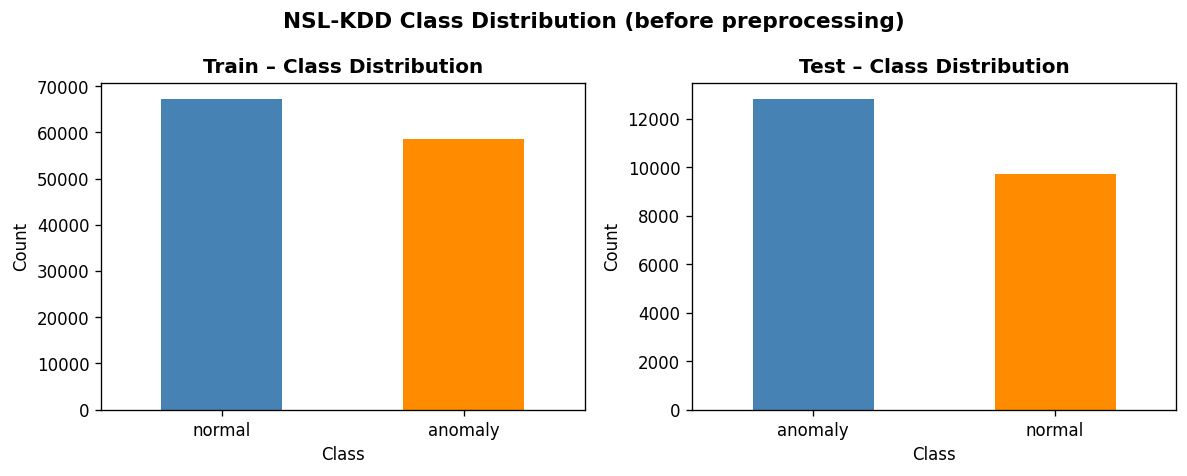

In [4]:
# ── Class distribution ────────────────────────────────────────────────────
train_counts = df_train[LABEL_COL].value_counts()
test_counts  = df_test[LABEL_COL].value_counts()

print('Train label distribution:')
print(train_counts.to_string())
print()
print('Test label distribution:')
print(test_counts.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=120)
train_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'darkorange'])
ax1.set_title('Train – Class Distribution', fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

test_counts.plot(kind='bar', ax=ax2, color=['steelblue', 'darkorange'])
ax2.set_title('Test – Class Distribution', fontweight='bold')
ax2.set_xlabel('Class')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=0)

plt.suptitle('NSL-KDD Class Distribution (before preprocessing)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig_01_class_dist_raw.png', dpi=120, bbox_inches='tight')
plt.show()

In [5]:
# ── dtypes overview ───────────────────────────────────────────────────────
print('Column dtypes (training set):')
print(df_train.dtypes.to_string())

Column dtypes (training set):
duration                       float64
protocol_type                      str
service                            str
flag                               str
src_bytes                      float64
dst_bytes                      float64
land                               str
wrong_fragment                 float64
urgent                         float64
hot                            float64
num_failed_logins              float64
logged_in                          str
num_compromised                float64
root_shell                     float64
su_attempted                   float64
num_root                       float64
num_file_creations             float64
num_shells                     float64
num_access_files               float64
num_outbound_cmds              float64
is_host_login                      str
is_guest_login                     str
count                          float64
srv_count                      float64
serror_rate                    flo

## 3 · Feature Engineering

Steps applied **identically to train and test**:
1. Drop zero-variance column
2. Binary-string columns → integer
3. One-hot encode nominal categoricals (using **train** vocabulary to avoid leakage)

In [6]:
def engineer_features(df_tr, df_te, cat_cols, bin_cols, drop_cols, label_col):
    """
    Apply feature engineering to train and test DataFrames.
    The one-hot vocabulary is derived from the training set only.
    Returns (X_train_df, X_test_df, y_train_series, y_test_series).
    """
    # Separate labels
    y_tr = df_tr[label_col].copy()
    y_te = df_te[label_col].copy()

    X_tr = df_tr.drop(columns=[label_col] + drop_cols, errors='ignore').copy()
    X_te = df_te.drop(columns=[label_col] + drop_cols, errors='ignore').copy()

    # Binary-string → int
    for col in bin_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].astype(int)
            X_te[col] = X_te[col].astype(int)

    # One-hot encode categoricals using training set vocabulary
    X_tr = pd.get_dummies(X_tr, columns=cat_cols)
    X_te = pd.get_dummies(X_te, columns=cat_cols)

    # Align columns: test may have fewer dummy columns than train
    X_tr, X_te = X_tr.align(X_te, join='left', axis=1, fill_value=0)

    return X_tr, X_te, y_tr, y_te


X_train, X_test, y_train, y_test = engineer_features(
    df_train, df_test,
    cat_cols=CAT_COLS,
    bin_cols=BIN_COLS,
    drop_cols=DROP_COLS,
    label_col=LABEL_COL,
)

feature_names = X_train.columns.tolist()

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'Features      : {len(feature_names)}')

X_train shape : (125973, 121)
X_test  shape : (22544, 121)
Features      : 121


## 4 · Label Encoding

In [7]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_enc = label_encoder.transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

class_names = label_encoder.classes_.tolist()
n_classes   = len(class_names)

print(f'Classes ({n_classes}): {class_names}')
print(f'y_train_enc shape : {y_train_enc.shape}')
print(f'y_test_enc  shape : {y_test_enc.shape}')
print()
print('Encoding mapping:')
for idx, name in enumerate(class_names):
    print(f'  {name} → {idx}')

# Save
joblib.dump(label_encoder, f'{MODEL_DIR}/label_encoder.pkl')
print(f'\n✓ label_encoder saved → {MODEL_DIR}/label_encoder.pkl')

Classes (2): ['anomaly', 'normal']
y_train_enc shape : (125973,)
y_test_enc  shape : (22544,)

Encoding mapping:
  anomaly → 0
  normal → 1

✓ label_encoder saved → ../../model/nsl-kdd/label_encoder.pkl


## 5 · Feature Scaling (MinMax 0–1)

Scaler fitted **only on `X_train`**  — applied to both splits.

In [8]:
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train.values)
X_test_sc  = scaler.transform(X_test.values)

print(f'Scaler fitted on {len(X_train):,} training samples.')
print(f'X_train_sc range: [{X_train_sc.min():.4f}, {X_train_sc.max():.4f}]')
print(f'X_test_sc  range: [{X_test_sc.min():.4f},  {X_test_sc.max():.4f}]')

# Save
joblib.dump(scaler, f'{MODEL_DIR}/scaler.pkl')
print(f'\n✓ Scaler saved → {MODEL_DIR}/scaler.pkl')

Scaler fitted on 125,973 training samples.
X_train_sc range: [0.0000, 1.0000]
X_test_sc  range: [0.0000,  2.5000]

✓ Scaler saved → ../../model/nsl-kdd/scaler.pkl


## 6 · Persist Processed Data

In [9]:
# NumPy arrays
np.save(f'{OUTPUT_DIR}/X_train_sc.npy', X_train_sc)
np.save(f'{OUTPUT_DIR}/X_test_sc.npy',  X_test_sc)
np.save(f'{OUTPUT_DIR}/y_train_enc.npy', y_train_enc)
np.save(f'{OUTPUT_DIR}/y_test_enc.npy',  y_test_enc)

# Raw label series (for later use in per-class visualisations)
y_train.reset_index(drop=True).to_json(f'{OUTPUT_DIR}/y_train_raw.json')
y_test.reset_index(drop=True).to_json(f'{OUTPUT_DIR}/y_test_raw.json')

# Metadata
meta = {
    'class_names'      : class_names,
    'n_classes'        : n_classes,
    'feature_names'    : feature_names,
    'n_features'       : len(feature_names),
    'selected_features': feature_names,   # All features passed to Notebook 02 for RF selection
}
with open(f'{OUTPUT_DIR}/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
for fname in ['X_train_sc.npy', 'X_test_sc.npy',
              'y_train_enc.npy', 'y_test_enc.npy',
              'y_train_raw.json', 'y_test_raw.json',
              'metadata.json']:
    fpath = f'{OUTPUT_DIR}/{fname}'
    size  = os.path.getsize(fpath)
    print(f'  {fpath}  ({size:,} bytes)')

Saved:
  ../../data/processed-nslkdd/X_train_sc.npy  (121,941,992 bytes)
  ../../data/processed-nslkdd/X_test_sc.npy  (21,822,720 bytes)
  ../../data/processed-nslkdd/y_train_enc.npy  (1,007,912 bytes)
  ../../data/processed-nslkdd/y_test_enc.npy  (180,480 bytes)
  ../../data/processed-nslkdd/y_train_raw.json  (2,215,035 bytes)
  ../../data/processed-nslkdd/y_test_raw.json  (384,972 bytes)
  ../../data/processed-nslkdd/metadata.json  (5,588 bytes)


## 7 · Post-processing Visualization

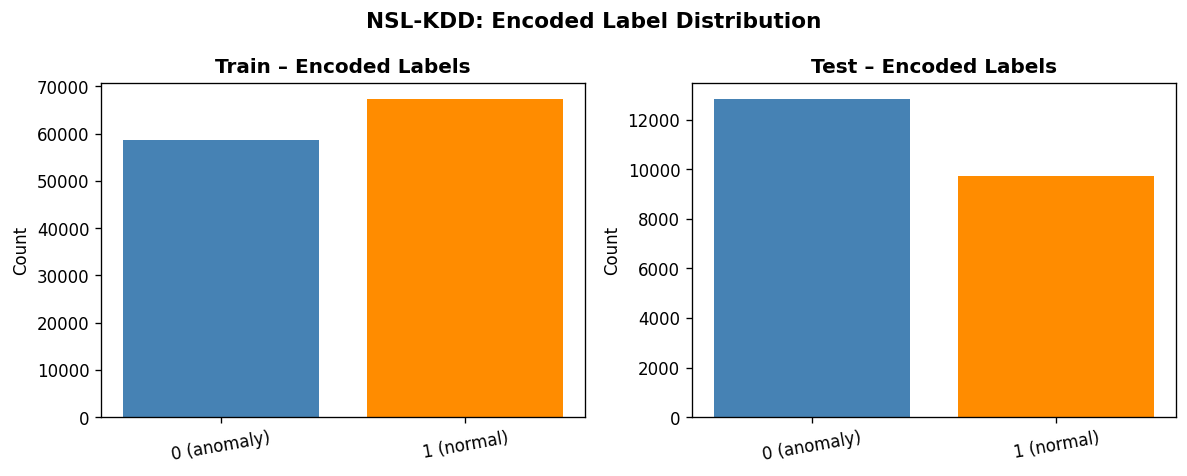


✓ Notebook 01 complete. Proceed to Notebook 02.


In [10]:
# ── Encoded label distribution ────────────────────────────────────────────
train_label_counts = pd.Series(y_train_enc).value_counts().sort_index()
test_label_counts  = pd.Series(y_test_enc).value_counts().sort_index()

tick_labels = [f'{i} ({class_names[i]})' for i in train_label_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=120)
ax1.bar(range(len(train_label_counts)), train_label_counts.values, color=['steelblue', 'darkorange'])
ax1.set_title('Train – Encoded Labels', fontweight='bold')
ax1.set_xticks(range(len(train_label_counts)))
ax1.set_xticklabels(tick_labels, rotation=10)
ax1.set_ylabel('Count')

ax2.bar(range(len(test_label_counts)), test_label_counts.values, color=['steelblue', 'darkorange'])
ax2.set_title('Test – Encoded Labels', fontweight='bold')
ax2.set_xticks(range(len(test_label_counts)))
ax2.set_xticklabels(tick_labels, rotation=10)
ax2.set_ylabel('Count')

plt.suptitle('NSL-KDD: Encoded Label Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig_02_class_dist_encoded.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n✓ Notebook 01 complete. Proceed to Notebook 02.')